In [133]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

In [134]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
job_array=False;index_adjust=0
ocean_fraction=2/8

In [135]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [136]:
#CL VS NONCL
################################################################

In [137]:
##########################################################
#PLOTTING

In [138]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [139]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [140]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_Combined_Entrainment"

In [141]:
# ################################
# #ENTRAINMENT DATA_TYPE SETUP #TESTING
# # PROCESSING=False #if using full entrainment calculations
# PROCESSING=True #if using turbulence-filtered entrainment calculations
# ################################

In [142]:
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3 + f"{data_type}_" + f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

CL_ALL_profile_array_C_TO_G
CL_ALL_profile_array_G_TO_C
CL_DEEP_profile_array_C_TO_G
CL_DEEP_profile_array_G_TO_C
CL_SHALLOW_profile_array_C_TO_G
CL_SHALLOW_profile_array_G_TO_C
nonCL_ALL_profile_array_C_TO_G
nonCL_ALL_profile_array_G_TO_C
nonCL_DEEP_profile_array_C_TO_G
nonCL_DEEP_profile_array_G_TO_C
nonCL_SHALLOW_profile_array_C_TO_G
nonCL_SHALLOW_profile_array_G_TO_C


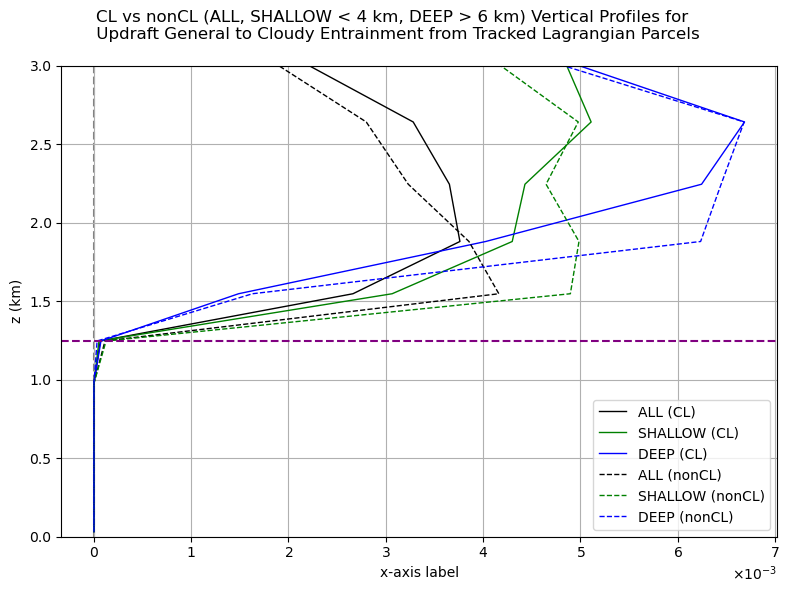

In [143]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (CL_ALL_profile_array_G_TO_C, CL_SHALLOW_profile_array_G_TO_C, CL_DEEP_profile_array_G_TO_C, 'G_TO_C', 'CL'),
    (nonCL_ALL_profile_array_G_TO_C, nonCL_SHALLOW_profile_array_G_TO_C, nonCL_DEEP_profile_array_G_TO_C, 'G_TO_C', 'nonCL')
]


cutoff_height=100
# z_cutoff=7.5
z_cutoff=np.where(CL_ALL_profile_array_G_TO_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for CL and nonCL
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]
    SHALLOW_profile=SHALLOW_profile[:z_cutoff]
    DEEP_profile=DEEP_profile[:z_cutoff]

    # Plot the profile for ALL (CL and nonCL) on top of each other
    if CLlabel == 'CL':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (CL)',lw=lw)
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (CL)',lw=lw)
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (CL)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonCL)',lw=lw)
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonCL)',lw=lw)
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonCL)',lw=lw)

    apply_scientific_notation([ax])



ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n Updraft General to Cloudy Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [144]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var='profile_array_G_TO_C'
cat='DEEP'
CL_DEEP_profile=globals()[f"CL_{cat}_{var}"]
cat='SHALLOW'
CL_SHALLOW_profile=globals()[f"CL_{cat}_{var}"]
globals()[f"CL_diff_{var}"] = average_difference(CL_DEEP_profile, CL_SHALLOW_profile)

var='profile_array_G_TO_C'
cat='DEEP'
nonCL_DEEP_profile=globals()[f"nonCL_{cat}_{var}"]
cat='SHALLOW'
nonCL_SHALLOW_profile=globals()[f"nonCL_{cat}_{var}"]

globals()[f"nonCL_diff_{var}"] = average_difference(nonCL_DEEP_profile, nonCL_SHALLOW_profile)

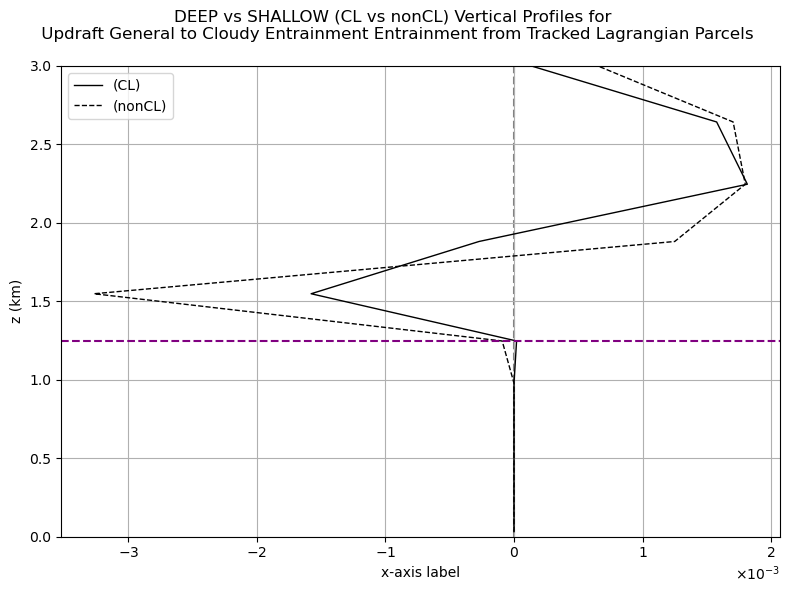

In [145]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (CL_diff_profile_array_G_TO_C,  'net', 'CL Diff'),
    (nonCL_diff_profile_array_G_TO_C,  'net', 'nonCL Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(CL_diff_profile_array_G_TO_C[:,1]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for CL and nonCL
for i, (ALL_profile, xlabel, CLlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (CL and nonCL) on top of each other
    if CLlabel == 'CL Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(CL)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(nonCL)',lw=lw)
    apply_scientific_notation([ax])

ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (CL vs nonCL) Vertical Profiles for \n Updraft General to Cloudy Entrainment Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [146]:
##########################################################################################
#SBZ vs nonSBZ Tracked Entrainment Profiles

In [147]:
##########################################################
#PLOTTING

In [148]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

SBZ_ALL_profile_array_C_TO_G
SBZ_ALL_profile_array_G_TO_C
SBZ_DEEP_profile_array_C_TO_G
SBZ_DEEP_profile_array_G_TO_C
SBZ_SHALLOW_profile_array_C_TO_G
SBZ_SHALLOW_profile_array_G_TO_C
nonSBZ_ALL_profile_array_C_TO_G
nonSBZ_ALL_profile_array_G_TO_C
nonSBZ_DEEP_profile_array_C_TO_G
nonSBZ_DEEP_profile_array_G_TO_C
nonSBZ_SHALLOW_profile_array_C_TO_G
nonSBZ_SHALLOW_profile_array_G_TO_C


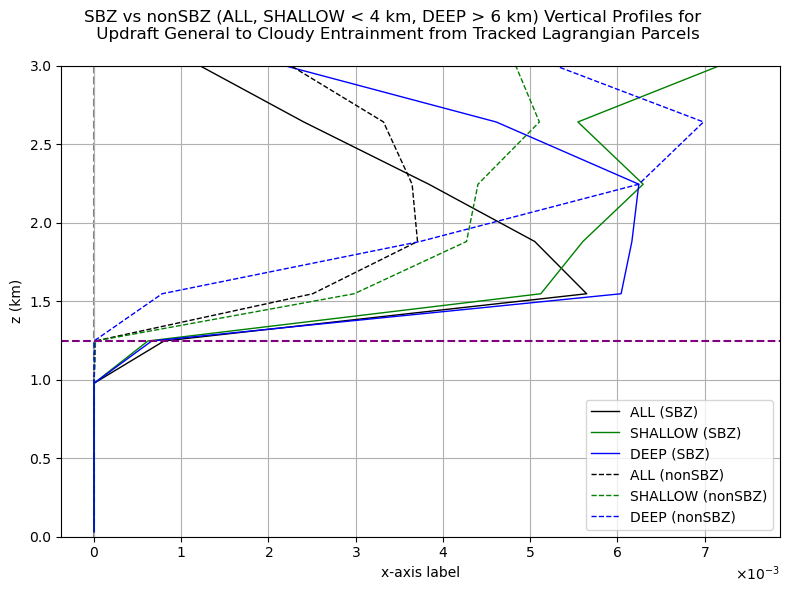

In [149]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_ALL_profile_array_G_TO_C, SBZ_SHALLOW_profile_array_G_TO_C, SBZ_DEEP_profile_array_G_TO_C, 'G_TO_C', 'SBZ'),
    (nonSBZ_ALL_profile_array_G_TO_C, nonSBZ_SHALLOW_profile_array_G_TO_C, nonSBZ_DEEP_profile_array_G_TO_C, 'G_TO_C', 'nonSBZ')
]


cutoff_height=100
# z_cutoff=7.5
z_cutoff=np.where(SBZ_ALL_profile_array_G_TO_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and nonSBZ
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]
    SHALLOW_profile=SHALLOW_profile[:z_cutoff]
    DEEP_profile=DEEP_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and nonSBZ) on top of each other
    if SBZlabel == 'SBZ':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)',lw=lw)
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)',lw=lw)
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonSBZ)',lw=lw)
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonSBZ)',lw=lw)
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonSBZ)',lw=lw)

    apply_scientific_notation([ax])



ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'SBZ vs nonSBZ (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n Updraft General to Cloudy Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [150]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
var='profile_array_G_TO_C'
cat='DEEP'
SBZ_DEEP_profile=globals()[f"SBZ_{cat}_{var}"]
cat='SHALLOW'
SBZ_SHALLOW_profile=globals()[f"SBZ_{cat}_{var}"]
globals()[f"SBZ_diff_{var}"] = average_difference(SBZ_DEEP_profile, SBZ_SHALLOW_profile)

var='profile_array_G_TO_C'
cat='DEEP'
nonSBZ_DEEP_profile=globals()[f"nonSBZ_{cat}_{var}"]
cat='SHALLOW'
nonSBZ_SHALLOW_profile=globals()[f"nonSBZ_{cat}_{var}"]

globals()[f"nonSBZ_diff_{var}"] = average_difference(nonSBZ_DEEP_profile, nonSBZ_SHALLOW_profile)

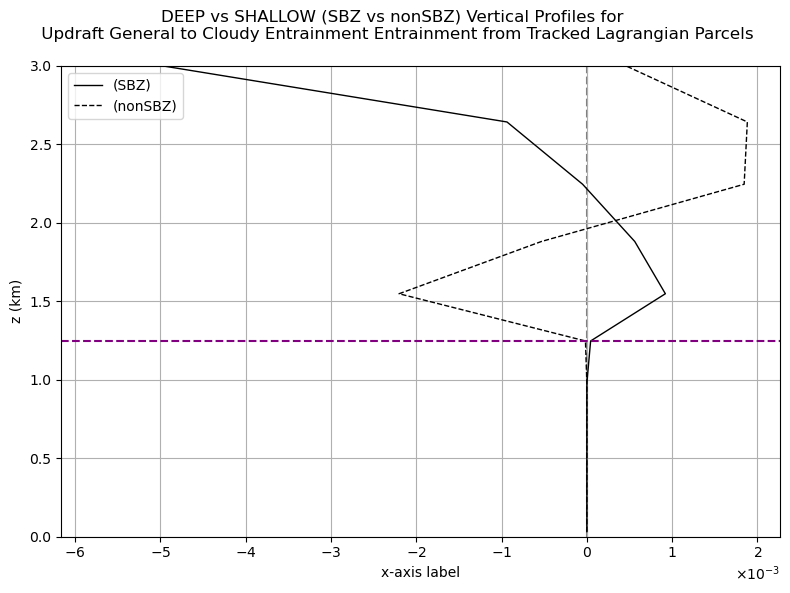

In [151]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_diff_profile_array_G_TO_C,  'net', 'SBZ Diff'),
    (nonSBZ_diff_profile_array_G_TO_C,  'net', 'nonSBZ Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_profile_array_G_TO_C[:,1]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and nonSBZ
for i, (ALL_profile, xlabel, SBZlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and nonSBZ) on top of each other
    if SBZlabel == 'SBZ Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(nonSBZ)',lw=lw)
    apply_scientific_notation([ax])


ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (SBZ vs nonSBZ) Vertical Profiles for \n Updraft General to Cloudy Entrainment Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [152]:
#ColdPool
################################################################

In [153]:
########################
#PLOTTING

In [154]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        print(key)

ColdPool_ALL_profile_array_C_TO_G
ColdPool_ALL_profile_array_G_TO_C
ColdPool_DEEP_profile_array_C_TO_G
ColdPool_DEEP_profile_array_G_TO_C
ColdPool_SHALLOW_profile_array_C_TO_G
ColdPool_SHALLOW_profile_array_G_TO_C


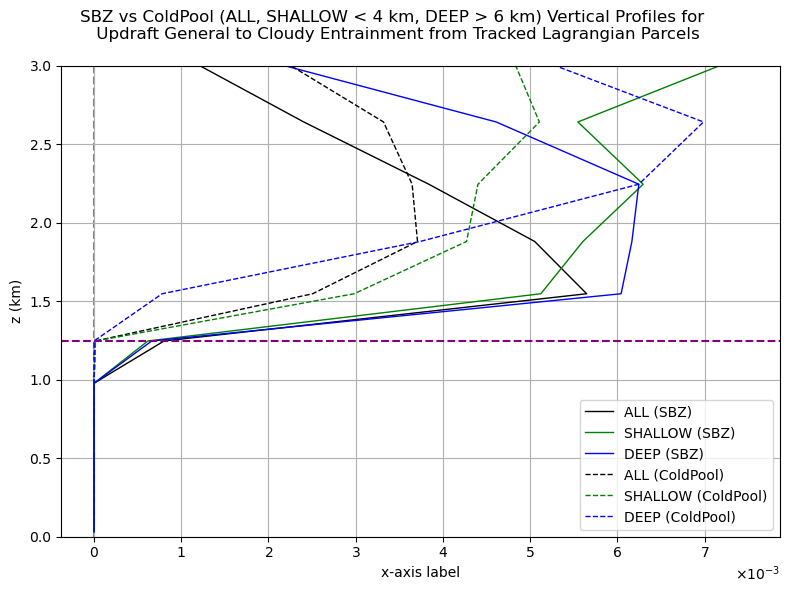

In [155]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_ALL_profile_array_G_TO_C, SBZ_SHALLOW_profile_array_G_TO_C, SBZ_DEEP_profile_array_G_TO_C, 'G_TO_C', 'SBZ'),
    (ColdPool_ALL_profile_array_G_TO_C, ColdPool_SHALLOW_profile_array_G_TO_C, ColdPool_DEEP_profile_array_G_TO_C, 'G_TO_C', 'ColdPool')
]


cutoff_height=100
# z_cutoff=7.5
z_cutoff=np.where(SBZ_ALL_profile_array_G_TO_C[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and ColdPool
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]
    SHALLOW_profile=SHALLOW_profile[:z_cutoff]
    DEEP_profile=DEEP_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and ColdPool) on top of each other
    if SBZlabel == 'SBZ':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)',lw=lw)
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)',lw=lw)
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (ColdPool)',lw=lw)
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (ColdPool)',lw=lw)
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (ColdPool)',lw=lw)

    apply_scientific_notation([ax])



ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'SBZ vs ColdPool (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n Updraft General to Cloudy Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()




In [156]:
#DIFFERENCE PLOT
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile
var='profile_array_G_TO_C'
cat='DEEP'
SBZ_DEEP_profile=globals()[f"SBZ_{cat}_{var}"]
cat='SHALLOW'
SBZ_SHALLOW_profile=globals()[f"SBZ_{cat}_{var}"]
globals()[f"SBZ_diff_{var}"] = average_difference(SBZ_DEEP_profile, SBZ_SHALLOW_profile)

var='profile_array_G_TO_C'
cat='DEEP'
ColdPool_DEEP_profile=globals()[f"ColdPool_{cat}_{var}"]
cat='SHALLOW'
ColdPool_SHALLOW_profile=globals()[f"ColdPool_{cat}_{var}"]

globals()[f"ColdPool_diff_{var}"] = average_difference(ColdPool_DEEP_profile, ColdPool_SHALLOW_profile)

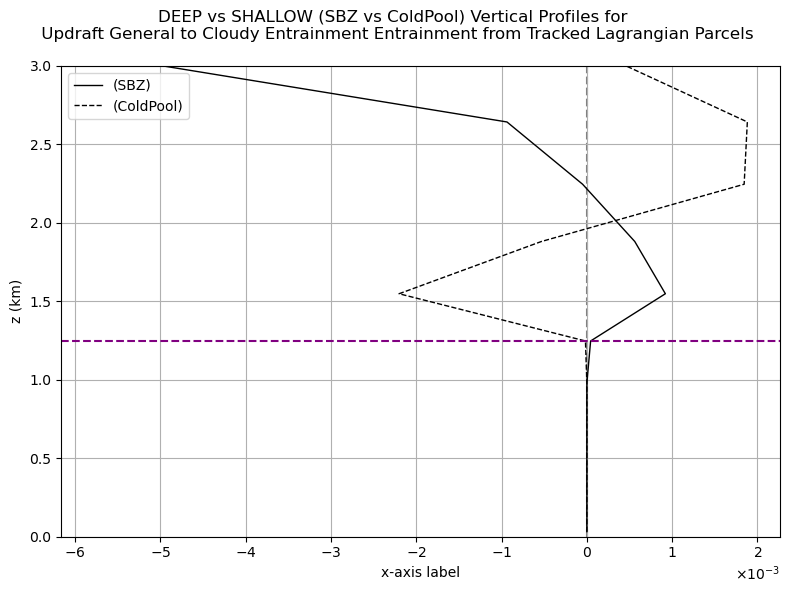

In [157]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt
lw=1

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_diff_profile_array_G_TO_C,  'net', 'SBZ Diff'),
    (ColdPool_diff_profile_array_G_TO_C,  'net', 'ColdPool Diff'),
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_profile_array_G_TO_C[:,1]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and ColdPool
for i, (ALL_profile, xlabel, SBZlabel) in enumerate(profiles):

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and ColdPool) on top of each other
    if SBZlabel == 'SBZ Diff':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='(SBZ)',lw=lw)
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='(ColdPool)',lw=lw)
    apply_scientific_notation([ax])

ax.set_ylim(0,3)

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

#MEAN CLOUD BASE
ax.axhline(all_cloudbase,color='purple',linestyle='dashed')

# Set up the main title and adjust layout
plt.suptitle(f'DEEP vs SHALLOW (SBZ vs ColdPool) Vertical Profiles for \n Updraft General to Cloudy Entrainment Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()


